In [1]:
import glob                        
import numpy as np                 
import pandas as pd
import matplotlib.pyplot as plt    
import seaborn as sns              
sns.set_theme()

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense, LSTM, Conv1D
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

ModuleNotFoundError: No module named 'numpy'

In [ ]:
DATASET_SRC = '/kaggle/input/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023'

## Data preprocessing

In [ ]:
df_states = pd.read_csv(f'{DATASET_SRC}/stations_info.csv')
df_states.drop(columns=['agency', 'station_location', 'start_month'], inplace=True)

In [ ]:
def combine_state_df(state_name):
    '''
    Combine all state files into a single dataframe and attaching the city information.
    '''
    
    state_code = df_states[df_states['state'] == state_name]['file_name'].iloc[0][:2]
    state_files = glob.glob(f'{DATASET_SRC}/{state_code}*.csv')
    print(f'Combining a total of {len(state_files)} files...\n')

    combined_df = []
    for state_file in state_files:
        file_name = state_file.split(f'{DATASET_SRC}/')[1][0:-4]
        file_df = pd.read_csv(state_file)
        file_df['city'] = df_states[df_states['file_name'] == file_name]['city'].values[0]
        file_df['city'] = file_df['city'].astype('string')
        combined_df.append(file_df)
        
    return pd.concat(combined_df)

In [ ]:
df = combine_state_df('Delhi')

Combining a total of 40 files...



In [ ]:
def create_dt_index(dataframe):
    dataframe = dataframe.drop(columns='To Date')
    dataframe['From Date'] = pd.to_datetime(dataframe['From Date'])
    dataframe = dataframe.rename(columns={'From Date': 'datetime'})
    return dataframe.set_index('datetime')

In [ ]:
df = create_dt_index(df)

In [ ]:
df

,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Benzene (ug/m3),...,O Xylene (ug/m3),CH4 (ug/m3),NMHC (ug/m3),SPM (ug/m3),THC (ug/m3),Gust (km/hr),MP-Xylene (),Eth-Benzene (),Xylene (),CH4 ()
datetime,,,,,,,,,,,,,,,,,,,,,
2020-11-13 14:00:00,142.70,390.00,0.57,17.92,18.48,48.87,2.78,0.83,39.24,2.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-13 15:00:00,130.43,326.85,1.58,17.61,19.19,56.64,2.69,0.71,30.93,2.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-13 16:00:00,114.45,274.28,3.96,24.29,28.26,86.66,2.45,0.84,26.15,2.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-13 17:00:00,148.47,292.00,14.84,37.68,52.52,114.45,2.50,1.65,22.16,3.42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-13 18:00:00,151.22,449.30,40.67,46.61,87.29,106.35,3.21,3.24,21.95,5.76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-31 19:00:00,28.95,40.40,NaN,61.47,NaN,NaN,11.87,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-31 20:00:00,59.88,72.47,NaN,76.23,NaN,NaN,12.46,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-31 21:00:00,368.03,373.25,NaN,72.86,NaN,NaN,8.48,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature reduction

In [ ]:
reduction_groups = {
    "Xylene (ug/m3)":    ["Xylene ()"],
    "MP-Xylene (ug/m3)": ["MP-Xylene ()"],
    "Benzene (ug/m3)":   ["Benzene ()"],
    "Toluene (ug/m3)":   ["Toluene ()"],
    "SO2 (ug/m3)":       ["SO2 ()"],
    "NOx (ug/m3)":       ["NOx (ppb)"],
    "Ozone (ug/m3)":     ["Ozone (ppb)"],
    "AT (degree C)":     ["AT ()"],
    "WD (degree)":       ["WD (degree C)", "WD (deg)", "WD ()"],
    "WS (m/s)":          ["WS ()"]
}

In [ ]:
def merge_columns(dataframe, columns):
    '''
    Merges column records into a single column.
    '''
    
    for column, cols_to_merge in columns.items():
        if column not in dataframe.columns and any(name in dataframe.columns for name in cols_to_merge):
            dataframe[column] = np.nan

        for col_name in cols_to_merge:
            if col_name in dataframe.columns:
                dataframe[column] = dataframe[column].fillna(dataframe[col_name])
                dataframe = dataframe.drop(columns=[col_name])
            
    return dataframe

In [ ]:
df = merge_columns(df, reduction_groups)

## Drop missing values

In [ ]:
df = df.dropna(how='all')
df = df.dropna(how='all', axis='columns')

In [ ]:
threshold = 0.6
df = df.dropna(thresh=df.shape[0]*threshold, axis=1)

## Feature engineering

In [ ]:
df = df.drop(['NO (ug/m3)', 'NO2 (ug/m3)'], axis=1)

## Resampling

In [ ]:
df = df.resample('60min').mean(numeric_only=True)

## Outlier detection and removal

In [ ]:
df['PM2.5 (ug/m3)'] = df['PM2.5 (ug/m3)'].mask(df['PM2.5 (ug/m3)'].gt(950))
df['CO (mg/m3)'] = df['CO (mg/m3)'].mask(((df.index > '2015') & df['CO (mg/m3)'].gt(35)))
df['Ozone (ug/m3)'] = df['Ozone (ug/m3)'].mask(df['Ozone (ug/m3)'].gt(185))
df['NOx (ug/m3)'] = df['NOx (ug/m3)'].mask((
    ((df.index < '2013') & (df['NOx (ug/m3)'].gt(380))) |
    ((df.index > '2015') & (df.index < '2016') & (df['NOx (ug/m3)'].gt(400))) |
    ((df.index > '2016') & (df['NOx (ug/m3)'].gt(450)))
))

In [ ]:
df = df.interpolate(method='pad')
df = df.fillna(df.mean())

/var/folders/zw/s3y2r3sj6vb02cy4m1tpyqy80000gn/T/ipykernel_49181/3343059986.py:1: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='pad')


In [ ]:
date_time = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S')
timestamp = date_time.map(pd.Timestamp.timestamp)

In [ ]:
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp * (2 * np.pi / year))

DATETIME_FEATURES = ['Day sin', 'Day cos', 'Year sin', 'Year cos']

Text(0.5, 1.0, 'Time of day signal')

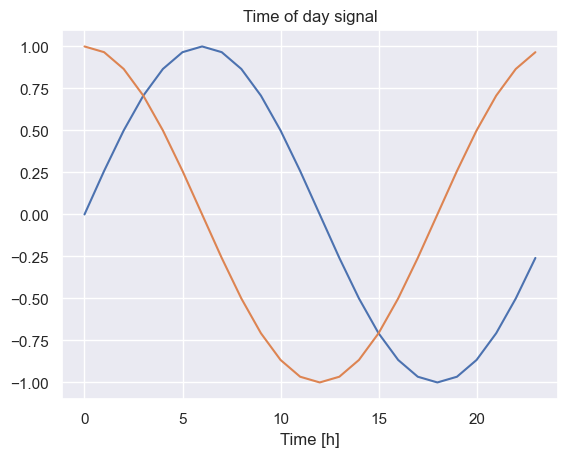

In [ ]:
plt.plot(np.array(df['Day sin'])[:24])
plt.plot(np.array(df['Day cos'])[:24])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [ ]:
df = df.query('datetime > 2014')

In [ ]:
df.head()

,PM2.5 (ug/m3),CO (mg/m3),Ozone (ug/m3),NOx (ug/m3),Day sin,Day cos,Year sin,Year cos
datetime,,,,,,,,
2014-01-01 01:00:00,78.525000,9.9420,12.040000,46.524000,0.258819,0.965926,0.006394,0.999980
2014-01-01 02:00:00,104.290000,3.7475,9.910000,49.303333,0.500000,0.866025,0.007110,0.999975
2014-01-01 03:00:00,144.743333,11.3025,4.265000,49.328000,0.707107,0.707107,0.007827,0.999969
2014-01-01 04:00:00,147.760000,19.7825,5.396667,41.965000,0.866025,0.500000,0.008544,0.999963
2014-01-01 05:00:00,171.950000,9.3200,5.466667,41.580000,0.965926,0.258819,0.009261,0.999957


In [ ]:
df.shape

(81047, 8)

## Split the data

In [ ]:
val_split = 0.2
test_split = 0.1
n = len(df)

train_df = df[0:int(n*(1-val_split))]
val_df = df[int(n*(1-(val_split+test_split))):int(n*(1-test_split))]
test_df = df[int(n*(1-test_split)):]

## Normalization

In [ ]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

## Time Series Forecasting

In [ ]:
class WindowGenerator():
    def __init__(self, input_width, label_width, label_columns, offset, train_df=train_df, val_df=val_df, test_df=test_df):
        '''
        Initializes a WindowGenerator object (based on the Tensorflow tutorial on Time series forecasting).
        '''
        
        self.train_df = train_df[label_columns + DATETIME_FEATURES]
        self.val_df = val_df[label_columns + DATETIME_FEATURES]
        self.test_df = test_df[label_columns + DATETIME_FEATURES]
        
        self.column_indices = {name: i for i, name in enumerate(self.train_df.columns)}
        self.label_columns = label_columns
        self.label_columns_indices = [self.column_indices[feature] for feature in self.label_columns]
        
        self.input_width = input_width
        self.label_width = label_width
        self.offset = offset
        self.window_size = self.input_width + self.offset

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.window_size)[self.input_slice]

        self.label_start = self.window_size - self.label_width
        self.label_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.window_size)[self.label_slice]

        self._initialize_sets()

    def _initialize_sets(self):  
        self._train = self.split_window(self.train_df)
        self._val = self.split_window(self.val_df)
        self._test = self.split_window(self.test_df)
        
    def __repr__(self):
        return '\n'.join([f'Total window size: {self.window_size}',
                          f'Input indices: {self.input_indices}',
                          f'Label indices: {self.label_indices}',
                          f'Target features: {self.label_columns}'])

In [ ]:
def split_window(self, data):
    '''
    Convert the provided dataset into windows of features and labels.
    '''
    
    np_df = np.array(data)
    inputs = []
    labels = []
    
    for i in range(len(np_df) - self.window_size):
        current_window = np_df[i:i+self.window_size]
        inputs.append(current_window[self.input_slice])
        labels.append(current_window[self.label_slice, self.label_columns_indices])
    return np.array(inputs), np.array(labels)

WindowGenerator.split_window = split_window

In [ ]:
@property
def train(self):
    return self._train

@property
def val(self):
    return self._val

@property
def test(self):
    return self._test

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test

In [ ]:
@property
def data_shapes(self):
    '''
    Helper function to showcase the shapes of the sets of the window.
    '''
    print('\n'.join([f'Train:\t {self._train[0].shape} | {self._train[1].shape}',
                     f'Val:\t {self._val[0].shape} | {self._val[1].shape}',
                     f'Test:\t {self._test[0].shape} | {self._test[1].shape}']))

WindowGenerator.data_shapes = data_shapes

In [ ]:
@property
def get_model_params(self):
    '''
    Helper function to get and showcase the parameters to be used by the models.
    '''
    
    n_steps = self.train[0].shape[1]
    
    n_features = self.train_df.shape[1]
    
    n_outputs = self.train[1].shape[-1]

    print('\n'.join([f'Number of time steps: {n_steps}',
                     f'Number of input features: {n_features}',
                     f'Number of output features: {n_outputs}']))

    return n_steps, n_features, n_outputs

WindowGenerator.get_model_params = get_model_params

In [ ]:
single_step_window = WindowGenerator(input_width=24, label_width=1, offset=1, label_columns=['PM2.5 (ug/m3)'])
single_step_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24]
Target features: ['PM2.5 (ug/m3)']

In [ ]:
single_step_window.data_shapes

Train:	 (64812, 24, 5) | (64812, 1, 1)
Val:	 (16185, 24, 5) | (16185, 1, 1)
Test:	 (8080, 24, 5) | (8080, 1, 1)


In [ ]:
n_steps, n_features, n_outputs = single_step_window.get_model_params

Number of time steps: 24
Number of input features: 5
Number of output features: 1


## Using CNN-LSTM

In [ ]:
cnn_lstm = tf.keras.Sequential([
    Input(shape=(n_steps, n_features)),
    Conv1D(filters=32, kernel_size=(n_steps), activation='relu'),
    LSTM(32),
    Dense(n_outputs, activation='linear')
])

In [ ]:
MAX_EPOCHS = 50
PATIENCE = 2
METRIC_NAME = 'mean_absolute_error'

In [ ]:
models = {
    "cnn_lstm": cnn_lstm
}

In [ ]:
def compile_and_fit(model, window, patience=PATIENCE, num_epochs=MAX_EPOCHS):
    '''
    Compiles and fits the model to the training and validation datasets.
    '''

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                      patience=PATIENCE,
                                                      mode='min',
                                                      restore_best_weights=True,
                                                      start_from_epoch=5)
    
    model.compile(optimizer = Adam(learning_rate = 0.001),
                  loss = MeanSquaredError(),
                  metrics = [MeanAbsoluteError()])

    history = model.fit(window.train[0], window.train[1],
                        validation_data=window.val,
                        epochs=MAX_EPOCHS,
                        callbacks=[early_stopping])

    return history

In [ ]:
print("Training [cnn_lstm] model architecture...")
cnn_lstm_history = compile_and_fit(models['cnn_lstm'], single_step_window)

Training [cnn_lstm] model architecture...
Epoch 1/50
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 3s 737us/step - loss: 0.0938 - mean_absolute_error: 0.1847 - val_loss: 0.0235 - val_mean_absolute_error: 0.0983
Epoch 2/50
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 1s 561us/step - loss: 0.0616 - mean_absolute_error: 0.1486 - val_loss: 0.0223 - val_mean_absolute_error: 0.0961
Epoch 3/50
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step - loss: 0.0595 - mean_absolute_error: 0.1432 - val_loss: 0.0248 - val_mean_absolute_error: 0.1057
Epoch 4/50
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step - loss: 0.0577 - mean_absolute_error: 0.1404 - val_loss: 0.0227 - val_mean_absolute_error: 0.0941
Epoch 5/50
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 1s 568us/step - loss: 0.0571 - mean_absolute_error: 0.1397 - val_loss: 0.0233 - val_mean_absolute_error: 0.0970
Epoch 6/50
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - loss: 0.0558 - mean_absolute_error: 0.1364 - val_loss: 0.0201 - val_mean_absolute_error: 0.0923
Epoch 7/50
2026/2026 ━━━━━━━━━━━━━

In [ ]:
def plot_errors(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(cnn_lstm_history.history[METRIC_NAME])
    axes[1].plot(cnn_lstm_history.history[f'val_{METRIC_NAME}'])

    axes[0].set_title(METRIC_NAME)
    axes[1].set_title(f'Validation {METRIC_NAME}')

    axes[0].set_xlabel("Epochs")
    axes[1].set_xlabel("Epochs")

    axes[0].set_ylabel(METRIC_NAME)
    axes[1].set_ylabel(f'Validation {METRIC_NAME}')

    plt.show()

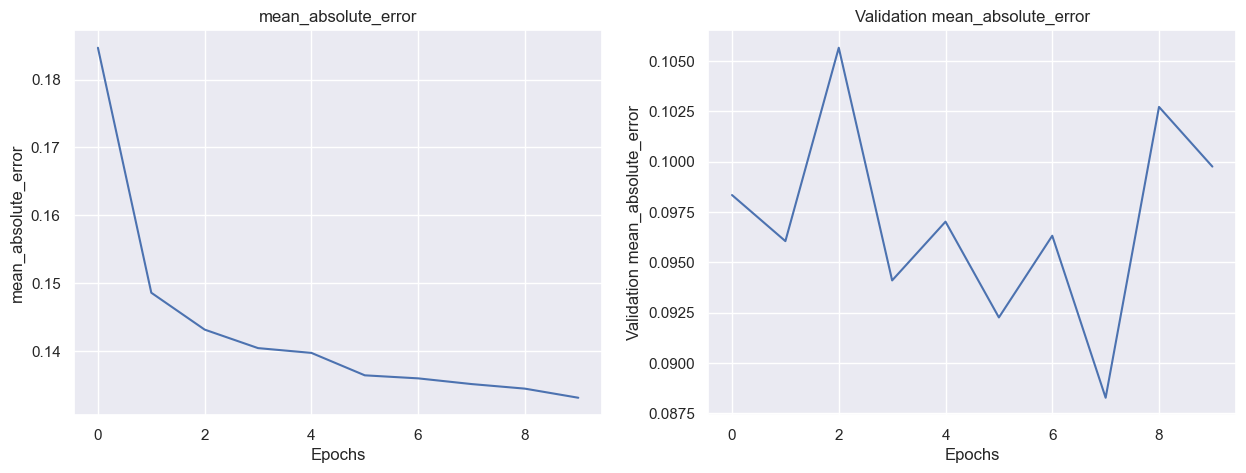

In [ ]:
plot_errors(cnn_lstm_history)

In [ ]:
best_val_mse = min(cnn_lstm_history.history['val_loss'])
best_val_mae = min(cnn_lstm_history.history[f'val_{METRIC_NAME}'])

print("Validation MSE:", best_val_mse)
print("Validation MAE:", best_val_mae)

Validation MSE: 0.018531307578086853
Validation MAE: 0.08827583491802216


In [ ]:
val_performance = {}
performance = {}

for model_arch, model in models.items():
    val_performance[model_arch] = model.evaluate(single_step_window.val[0], single_step_window.val[1])
    performance[model_arch] = model.evaluate(single_step_window.test[0], single_step_window.test[1], verbose=0)

506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step - loss: 0.0185 - mean_absolute_error: 0.0883


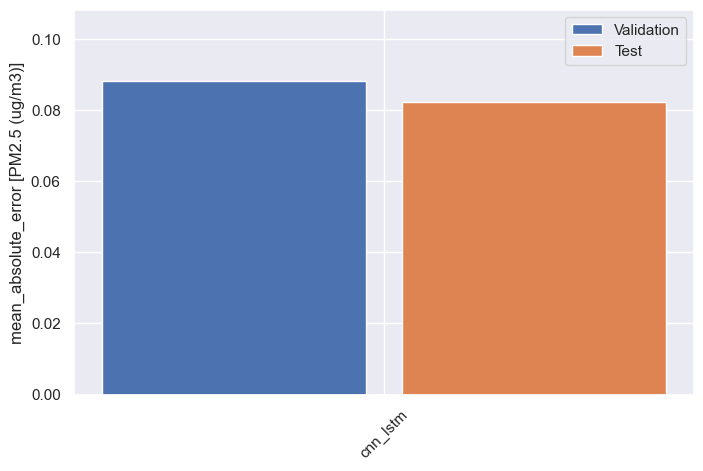

In [ ]:
x = np.arange(len(performance))
width = 0.3
val_mae = [val_performance[model][1] for model in list(models.keys())]
test_mae = [performance[model][1] for model in list(models.keys())]

ax = plt.figure(figsize=(8, 5))
plt.ylabel(f'{METRIC_NAME} [PM2.5 (ug/m3)]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.gca().set_ylim(0, max(val_mae+test_mae)+0.02)
plt.xticks(ticks=x, labels=models.keys(), rotation=45)
_ = plt.legend()

## Live Data Fetch – Open-Meteo API

Fetch the most recent hourly air-quality data for **Delhi** from the Open-Meteo API.
We retrieve the same pollutants the model was trained on (PM2.5, CO, Ozone, NOx) plus the
cyclical time features so we can run an immediate prediction.


In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timezone

DELHI_LAT  = 28.6139
DELHI_LON  = 77.2090

# Hourly data
OPENMETEO_VARS = [
    "pm2_5",          # → PM2.5 (ug/m3)   ← our prediction target
    "carbon_monoxide",# → CO  (ug/m3, API) – will convert to mg/m3
    "ozone",          # → Ozone (ug/m3)
    "nitrogen_dioxide"# → NO2 proxy for NOx
]

def fetch_openmeteo(lat: float, lon: float, vars: list, past_days: int = 5) -> pd.DataFrame:
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude":  lat,
        "longitude": lon,
        "hourly":    ",".join(vars),
        "past_days": past_days,  # extra history so we have >= 24 h for the window
        "timezone":  "auto",
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")
    df.index.name = "datetime"

    # Rename to match training column names
    df = df.rename(columns={
        "pm2_5":           "PM2.5 (ug/m3)",
        "carbon_monoxide": "CO (ug/m3_raw)",  # API unit: μg/m³
        "ozone":           "Ozone (ug/m3)",
        "nitrogen_dioxide": "NOx (ug/m3)",
    })

    df["CO (mg/m3)"] = df["CO (ug/m3_raw)"] / 1000.0
    df = df.drop(columns=["CO (ug/m3_raw)"])

    return df

print("Fetching live air-quality data from Open-Meteo …")
live_df = fetch_openmeteo(DELHI_LAT, DELHI_LON, OPENMETEO_VARS, past_days=5)
print(f"Fetched {len(live_df)} hourly rows  ({live_df.index[0]}  →  {live_df.index[-1]})")
live_df.tail()

Fetching live air-quality data from Open-Meteo …
Fetched 240 hourly rows  (2026-04-07 00:00:00  →  2026-04-16 23:00:00)


,PM2.5 (ug/m3),Ozone (ug/m3),NOx (ug/m3),CO (mg/m3)
datetime,,,,
2026-04-16 19:00:00,68.7,95.0,30.6,0.518
2026-04-16 20:00:00,76.1,74.0,37.9,0.683
2026-04-16 21:00:00,81.0,66.0,37.2,0.952
2026-04-16 22:00:00,84.1,65.0,32.2,1.258
2026-04-16 23:00:00,81.5,66.0,27.1,1.394


### Add cyclical time features to live data

Mirror the same `Day sin / cos` and `Year sin / cos` engineering applied during training.


In [ ]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add the same cyclical time features used during training."""
    timestamp = df.index.map(pd.Timestamp.timestamp)
    day  = 24 * 60 * 60
    year = 365.2425 * day
    df = df.copy()
    df["Day sin"]  = np.sin(timestamp * (2 * np.pi / day))
    df["Day cos"]  = np.cos(timestamp * (2 * np.pi / day))
    df["Year sin"] = np.sin(timestamp * (2 * np.pi / year))
    df["Year cos"] = np.cos(timestamp * (2 * np.pi / year))
    return df

live_df = add_time_features(live_df)

# Keep only the columns the model expects
MODEL_COLS = ["PM2.5 (ug/m3)", "CO (mg/m3)", "Ozone (ug/m3)", "NOx (ug/m3)",
              "Day sin", "Day cos", "Year sin", "Year cos"]

live_df = live_df[MODEL_COLS]

# Forward-fill then mean-fill any NaNs
live_df = live_df.ffill().fillna(live_df.mean())

print("Live dataframe shape:", live_df.shape)
live_df.tail()

Live dataframe shape: (240, 8)


,PM2.5 (ug/m3),CO (mg/m3),Ozone (ug/m3),NOx (ug/m3),Day sin,Day cos,Year sin,Year cos
datetime,,,,,,,,
2026-04-16 19:00:00,68.7,0.518,95.0,30.6,-0.965926,0.258819,0.967325,-0.253541
2026-04-16 20:00:00,76.1,0.683,74.0,37.9,-0.866025,0.500000,0.967143,-0.254234
2026-04-16 21:00:00,81.0,0.952,66.0,37.2,-0.707107,0.707107,0.966960,-0.254928
2026-04-16 22:00:00,84.1,1.258,65.0,32.2,-0.500000,0.866025,0.966777,-0.255621
2026-04-16 23:00:00,81.5,1.394,66.0,27.1,-0.258819,0.965926,0.966594,-0.256314


### Predict next-hour PM2.5 from live data

Normalize the live window with the *training* mean / std,  
then run one inference pass through the CNN-LSTM model.


In [ ]:
# label_col + DATETIME_FEATURES  →  5 features
MODEL_INPUT_COLS = ["PM2.5 (ug/m3)", "Day sin", "Day cos", "Year sin", "Year cos"]

def predict_next_hour(model, live_df: pd.DataFrame,
                      train_mean: pd.Series, train_std: pd.Series,
                      label_cols: list, input_width: int = 24) -> dict:
    live_input = live_df[MODEL_INPUT_COLS]
    norm = (live_input - train_mean[MODEL_INPUT_COLS]) / train_std[MODEL_INPUT_COLS]
    window_norm = norm.iloc[-input_width:]


    x = np.expand_dims(window_norm.values, axis=0)  # shape (1, 24, 5)
    y_norm = model.predict(x, verbose=0)             # shape (1, 1, 1) or (1, 1)

    results = {}
    for i, col in enumerate(label_cols):
        pred_norm = float(y_norm[0, 0, i]) if y_norm.ndim == 3 else float(y_norm[0, i])
        pred_real  = pred_norm * train_std[col] + train_mean[col]
        results[col] = round(pred_real, 2)

    return results

# Run prediction
label_cols = ["PM2.5 (ug/m3)"]

preds = predict_next_hour(
    model      = cnn_lstm,
    live_df    = live_df,
    train_mean = train_mean,
    train_std  = train_std,
    label_cols = label_cols,
)

next_hour = live_df.index[-1] + pd.Timedelta(hours=1)
print(f"\n{'='*55}")
print(f"  Live Prediction  →  {next_hour.strftime('%Y-%m-%d %H:%M')}")
for col, val in preds.items():
    print(f"  {col:25s}: {val:.2f}")
print(f"{'='*55}")


  Live Prediction  →  2026-04-17 00:00
  PM2.5 (ug/m3)            : 85.65


## Inline Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

def build_windows(norm_df: pd.DataFrame,
                  label_cols: list,
                  input_width: int = 24) -> tuple:
    """
    Convert a (T × F) normalized DataFrame into
      X: (n_windows, input_width, F)
      y: (n_windows, 1, n_labels)
    using a 1-step-ahead prediction scheme.
    """
    arr = norm_df.values                          # (T, F)
    col_idx = [norm_df.columns.get_loc(c) for c in label_cols]

    Xs, ys = [], []
    for i in range(len(arr) - input_width):
        Xs.append(arr[i : i + input_width])          # (24, F)
        ys.append(arr[i + input_width, col_idx])     # (n_labels,)

    return np.array(Xs), np.expand_dims(np.array(ys), axis=1)  # y → (N,1,L)


def inline_update(model,
                  live_df: pd.DataFrame,
                  train_mean: pd.Series,
                  train_std: pd.Series,
                  label_cols: list,
                  input_width: int = 24,
                  inline_epochs: int = 2,
                  lr_factor: float = 0.01) -> dict:
    
    # Normalize live data with training statistics
    norm_live = (live_df - train_mean) / train_std

    # We need at least input_width + 1 rows to build even one (X, y) pair
    if len(norm_live) < input_width + 1:
        raise ValueError(
            f"Not enough live data for inline update. "
            f"Need ≥ {input_width + 1} rows, got {len(norm_live)}."
        )

    X_live, y_live = build_windows(norm_live, label_cols, input_width)
    print(f"  Inline mini-batch: {X_live.shape[0]} windows  "
          f"(X: {X_live.shape}, y: {y_live.shape})")

    pre_loss, pre_mae = model.evaluate(X_live, y_live, verbose=0)

    try:
        original_lr = float(model.optimizer.learning_rate)
    except Exception:
        original_lr = 0.001

    inline_lr = original_lr * lr_factor
    model.compile(
        optimizer=Adam(learning_rate=inline_lr),
        loss=MeanSquaredError(),
        metrics=[MeanAbsoluteError()]
    )

    history = model.fit(
        X_live, y_live,
        epochs=inline_epochs,
        batch_size=max(1, len(X_live)),   # single batch → 1 gradient step/epoch
        verbose=1
    )

    post_loss, post_mae = model.evaluate(X_live, y_live, verbose=0)

    report = {
        "n_windows":    int(X_live.shape[0]),
        "inline_epochs": inline_epochs,
        "inline_lr":     inline_lr,
        "pre_mse":       round(pre_loss,  6),
        "pre_mae":       round(pre_mae,   6),
        "post_mse":      round(post_loss, 6),
        "post_mae":      round(post_mae,  6),
    }
    return report

print("Inline-learning helpers defined ✓")

Inline-learning helpers defined ✓


### Run one inline update on the live data

We take all the hours fetched from the API (≈ 5 × 24 = 120 rows) and perform
a quick fine-tuning pass.  
In production you would call this every hour (e.g. from a cron job) so the
model continuously adapts to the current pollution regime.


In [ ]:
MODEL_INPUT_COLS = ["PM2.5 (ug/m3)", "Day sin", "Day cos", "Year sin", "Year cos"]

def inline_update(model,
                  live_df: pd.DataFrame,
                  train_mean: pd.Series,
                  train_std: pd.Series,
                  label_cols: list,
                  input_width: int = 24,
                  inline_epochs: int = 2,
                  lr_factor: float = 0.01) -> dict:

    # Slice to the 5 columns the model was trained on
    live_input = live_df[MODEL_INPUT_COLS]
    norm_live = (live_input - train_mean[MODEL_INPUT_COLS]) / train_std[MODEL_INPUT_COLS]

    if len(norm_live) < input_width + 1:
        raise ValueError(
            f"Not enough live data. Need ≥ {input_width + 1} rows, got {len(norm_live)}."
        )

    X_live, y_live = build_windows(norm_live, label_cols, input_width)
    print(f"  Inline mini-batch: {X_live.shape[0]} windows  "
          f"(X: {X_live.shape}, y: {y_live.shape})")

    pre_loss, pre_mae = model.evaluate(X_live, y_live, verbose=0)

    try:
        original_lr = float(model.optimizer.learning_rate)
    except Exception:
        original_lr = 0.001

    inline_lr = original_lr * lr_factor
    model.compile(
        optimizer=Adam(learning_rate=inline_lr),
        loss=MeanSquaredError(),
        metrics=[MeanAbsoluteError()]
    )

    history = model.fit(
        X_live, y_live,
        epochs=inline_epochs,
        batch_size=max(1, len(X_live)),
        verbose=1
    )

    post_loss, post_mae = model.evaluate(X_live, y_live, verbose=0)

    return {
        "n_windows":     int(X_live.shape[0]),
        "inline_epochs": inline_epochs,
        "inline_lr":     inline_lr,
        "pre_mse":       round(pre_loss,  6),
        "pre_mae":       round(pre_mae,   6),
        "post_mse":      round(post_loss, 6),
        "post_mae":      round(post_mae,  6),
    }

### Visualise: model predictions on live data (before & after update)


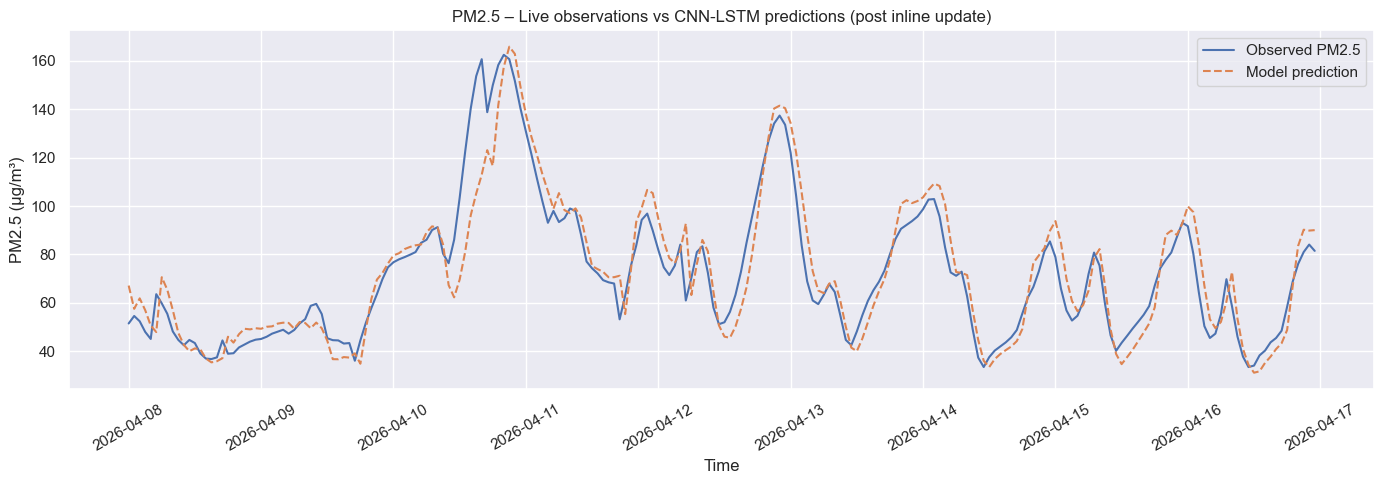

Live MAE (denormalized): 7.68 μg/m³


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

TARGET_COL  = "PM2.5 (ug/m3)"
INPUT_WIDTH = 24

norm_live = (live_df[MODEL_INPUT_COLS] - train_mean[MODEL_INPUT_COLS]) / train_std[MODEL_INPUT_COLS]
X_live, y_live = build_windows(norm_live, [TARGET_COL], INPUT_WIDTH)

# Predict
y_pred_norm = cnn_lstm.predict(X_live, verbose=0)  # (216, 1)
y_pred_norm = y_pred_norm.squeeze()                 # → (216,)

# Denormalise
std_pm  = train_std[TARGET_COL]
mean_pm = train_mean[TARGET_COL]

y_true_real = y_live.squeeze() * std_pm + mean_pm  # (216, 1, 1) → (216,)
y_pred_real = y_pred_norm      * std_pm + mean_pm  # (216,)

# Time axis
pred_times = live_df.index[INPUT_WIDTH:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pred_times, y_true_real, label="Observed PM2.5", linewidth=1.5)
ax.plot(pred_times, y_pred_real, label="Model prediction", linewidth=1.5, linestyle="--")
ax.set_title("PM2.5 – Live observations vs CNN-LSTM predictions (post inline update)")
ax.set_xlabel("Time")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

mae_live = float(np.mean(np.abs(y_true_real - y_pred_real)))
print(f"Live MAE (denormalized): {mae_live:.2f} μg/m³")

### Continuous-update loop

In [ ]:
import time

POLL_INTERVAL_SECONDS = 3600  # run every hour
MAX_ITERATIONS        = 3     # set to None for infinite loop

def run_continuous_loop(model, train_mean, train_std, label_cols,
                         poll_interval=POLL_INTERVAL_SECONDS,
                         max_iter=MAX_ITERATIONS):
    iteration = 0
    while max_iter is None or iteration < max_iter:
        ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
        print(f"\n[{ts}] Iteration {iteration + 1} – fetching live data …")

        try:
            ldf = fetch_openmeteo(DELHI_LAT, DELHI_LON, OPENMETEO_VARS, past_days=3)
            ldf = add_time_features(ldf)
            ldf = ldf[MODEL_COLS].ffill().fillna(ldf.mean())

            # --- inline update ---
            rpt = inline_update(model, ldf, train_mean, train_std,
                                label_cols, inline_epochs=1, lr_factor=0.01)
            print(f"  MSE {rpt['pre_mse']:.5f} → {rpt['post_mse']:.5f}")

            # --- next-hour prediction ---
            pred = predict_next_hour(model, ldf, train_mean, train_std, label_cols)
            next_h = ldf.index[-1] + pd.Timedelta(hours=1)
            print(f"  Forecast for {next_h}: {pred}")

        except Exception as exc:
            print(f"  ⚠  Error: {exc}")

        iteration += 1
        if max_iter is None or iteration < max_iter:
            print(f"  Sleeping {poll_interval // 60} min …")
            time.sleep(poll_interval)

    print("Loop finished.")

run_continuous_loop(cnn_lstm, train_mean, train_std,
                    label_cols=["PM2.5 (ug/m3)"],
                    poll_interval=0, max_iter=3)
print("Continuous-update loop helper defined.")
print("Uncomment the last two lines to execute it.")


[2026-04-12 18:19 UTC] Iteration 1 – fetching live data …
  Inline mini-batch: 168 windows  (X: (168, 24, 5), y: (168, 1, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step - loss: 0.0196 - mean_absolute_error: 0.0991
  MSE 0.01958 → 0.01947
  Forecast for 2026-04-17 00:00:00: {'PM2.5 (ug/m3)': np.float64(85.54)}
  Sleeping 0 min …

[2026-04-12 18:20 UTC] Iteration 2 – fetching live data …
  Inline mini-batch: 168 windows  (X: (168, 24, 5), y: (168, 1, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step - loss: 0.0195 - mean_absolute_error: 0.0987
  MSE 0.01947 → 0.01947
  Forecast for 2026-04-17 00:00:00: {'PM2.5 (ug/m3)': np.float64(85.54)}
  Sleeping 0 min …

[2026-04-12 18:20 UTC] Iteration 3 – fetching live data …
  Inline mini-batch: 168 windows  (X: (168, 24, 5), y: (168, 1, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step - loss: 0.0195 - mean_absolute_error: 0.0987
  MSE 0.01947 → 0.01947
  Forecast for 2026-04-17 00:00:00: {'PM2.5 (ug/m3)': np.float64(85.54)}
Loop finished.
Continuous-update loop 